# Explore secondary PDS groups

### Created by Shu, 20250718---

In [6]:
mu_time = [] # The time (tick) of mu peak---
mu_intensity = [] # The intensity of mu peak---
michel_time = []
michel_intensity = []

#Reminder: decay points here are corresponding to events after all (PDS & TPC) filters---
decayX = []
decayY = []
decayZ = []


# Open the text file and process each line
with open('./statResult/2ndPDS_muonTime_index.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                mu_time.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/2ndPDS_muonTime_intensity.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                number = float(parts[1].strip())
                mu_intensity.append(number)
            except ValueError:
                print(f"Error while reading mu_intensity.")

with open('./statResult/2ndPDS_michelTime_index.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                michel_time.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/2ndPDS_michelTime_intensity.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = float(parts[1].strip())
                michel_intensity.append(number)
            except ValueError:
                print(f"Error while reading")





print("\nLength of mu_time:", len(mu_time))
print("Length of mu_intensity:", len(mu_intensity))
print("Length of michel_time:", len(michel_time))
print("Length of michel_intensity:", len(michel_intensity))


print("\nMax vlaue of mu_intensity: ", max(mu_intensity))
print("Max vlaue of michel_intensity: ", max(michel_intensity))

#print(mu_intensity[:20])


Length of mu_time: 344
Length of mu_intensity: 344
Length of michel_time: 344
Length of michel_intensity: 344

Max vlaue of mu_intensity:  139.405
Max vlaue of michel_intensity:  54.1523


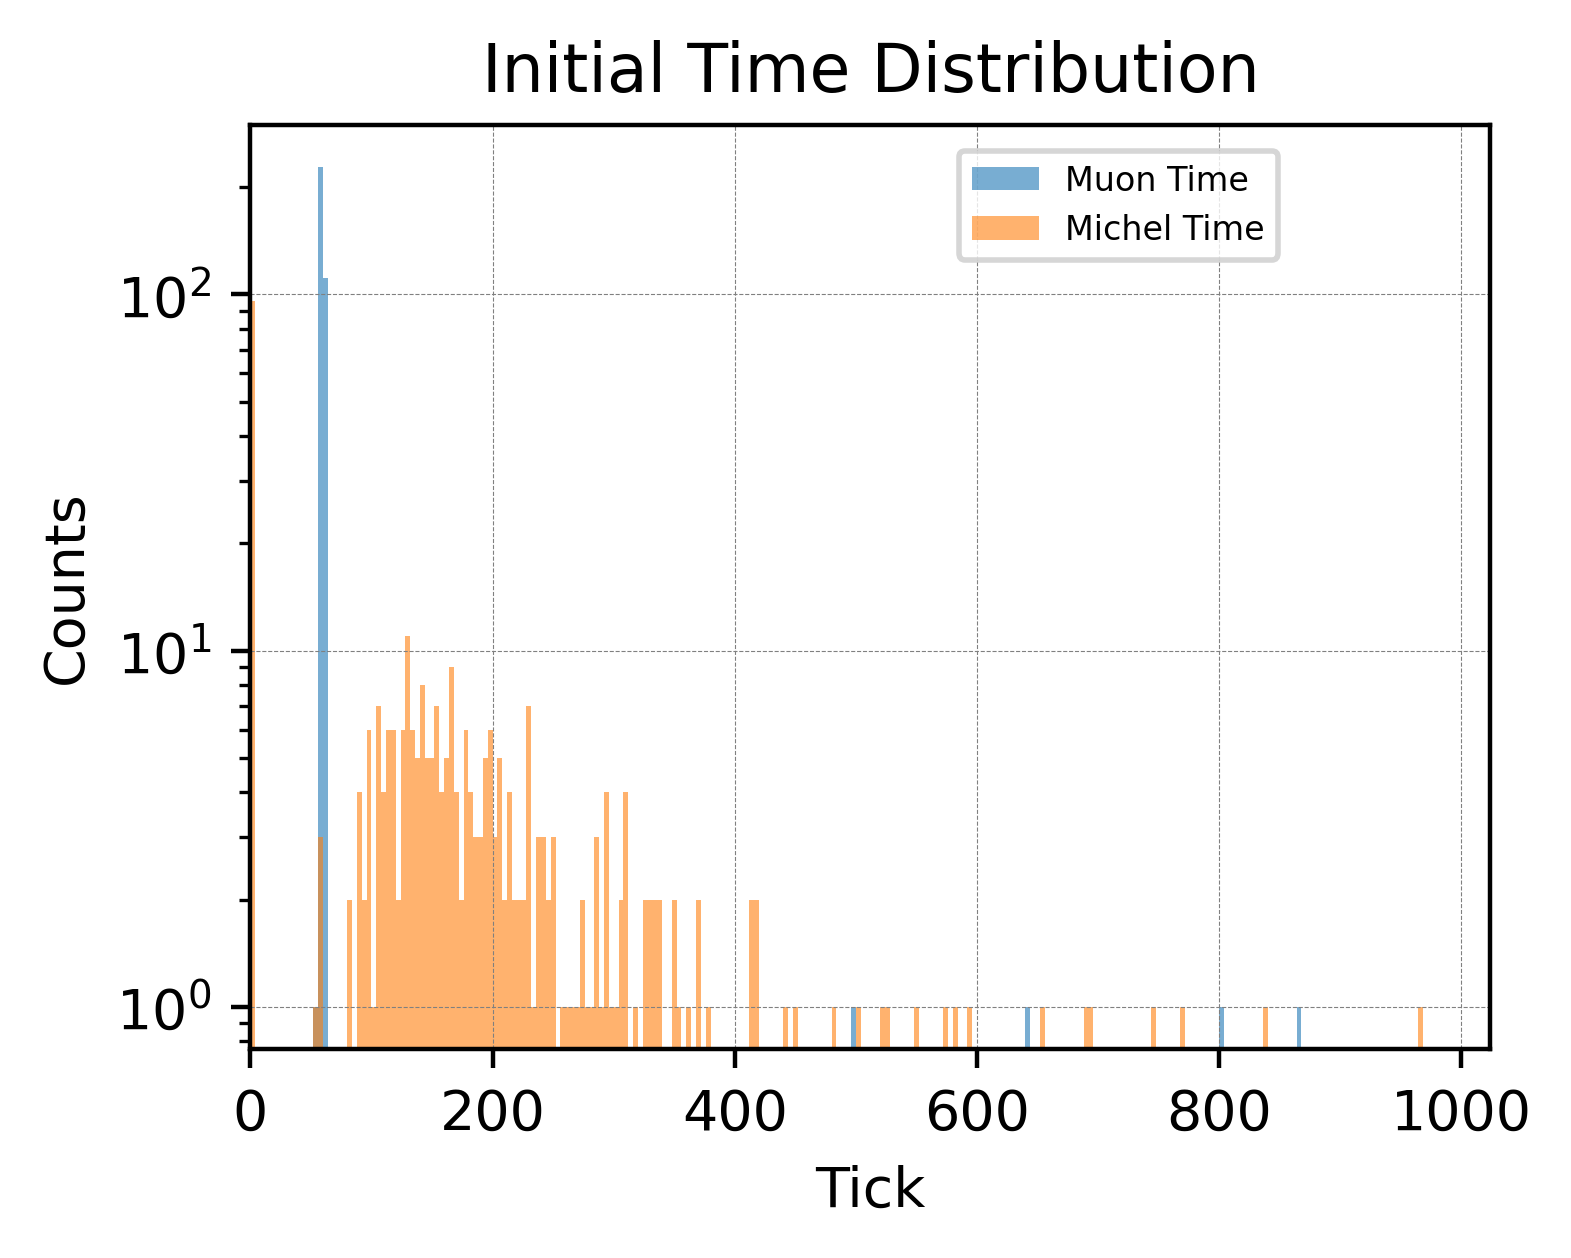

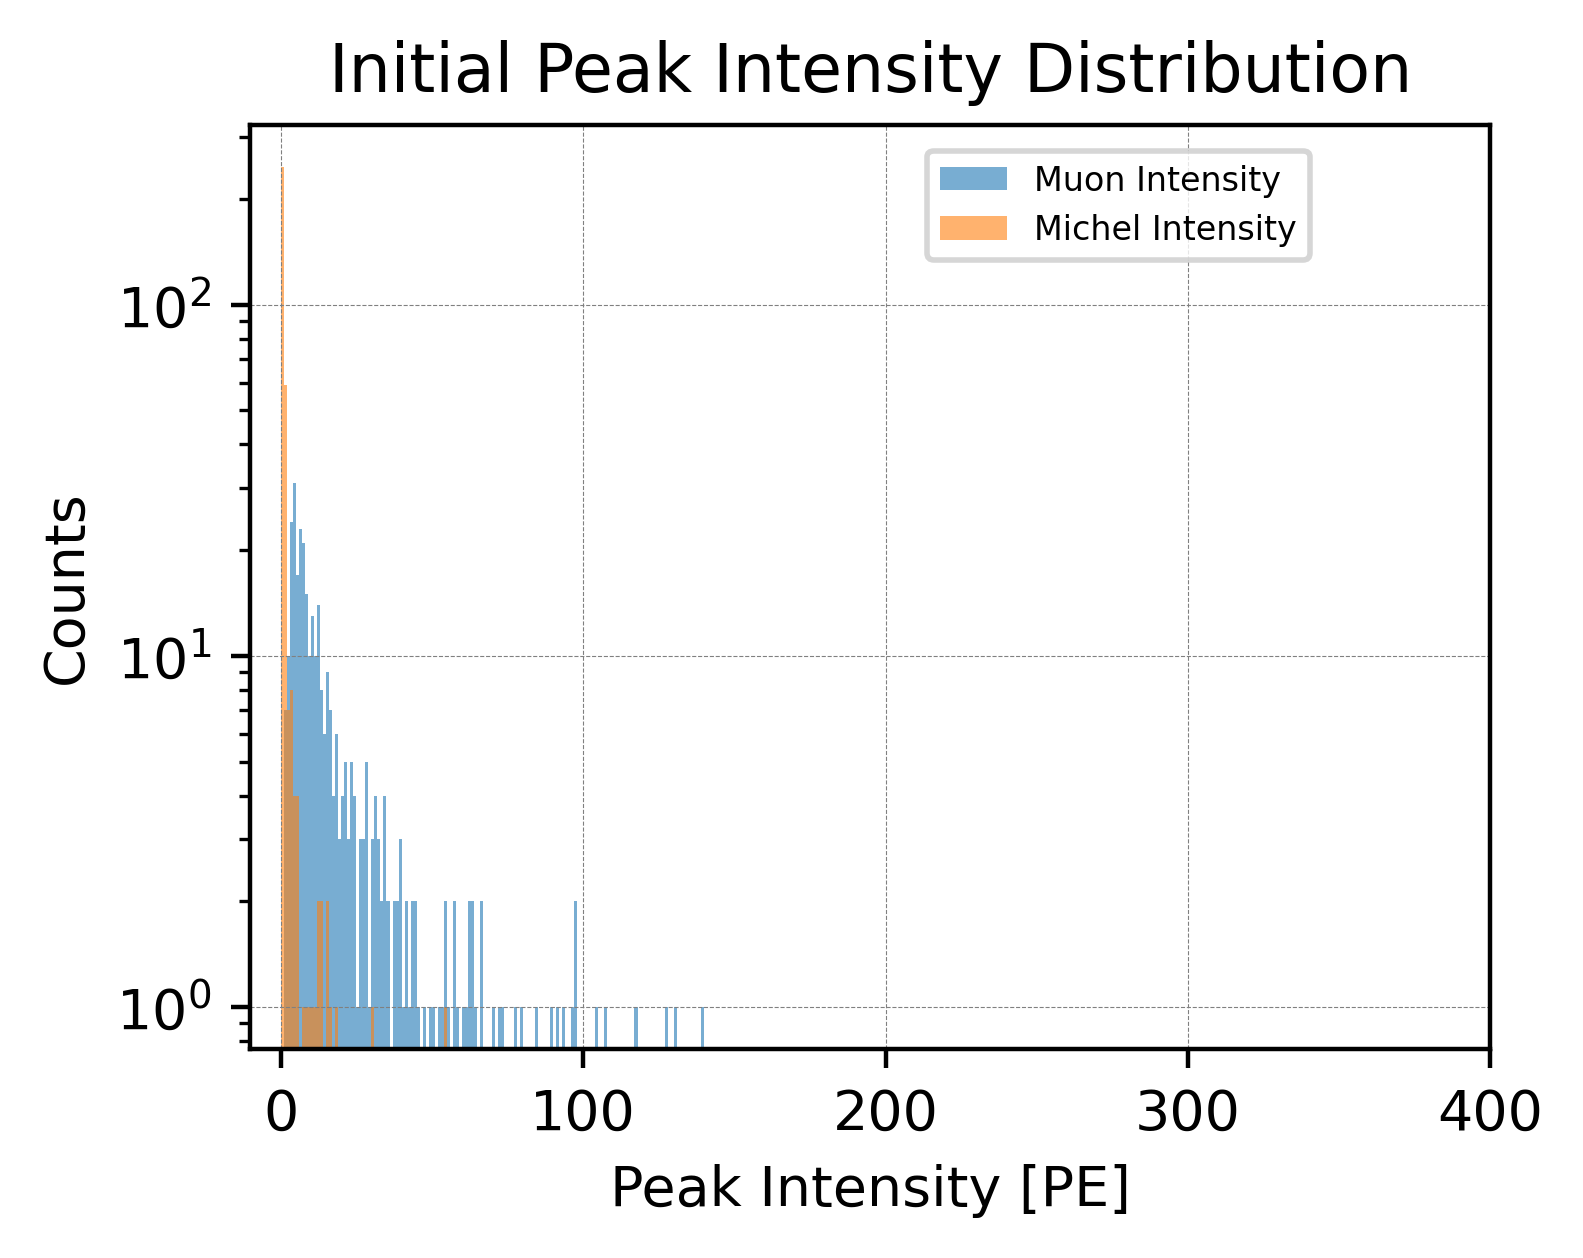

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465






#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(mu_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title('Initial Time Distribution')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()





#Initial Mu and Michel intensity distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = -1
range_max_initial = 400
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(mu_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('Peak Intensity [PE]')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-10, 400)
plt.title('Initial Peak Intensity Distribution')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()

<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals


Muon events purification (mu peak constrained to [55, 65]):

Purified Muon events:  340 (98.84%)
Length of updated michel_time      :  340
Length of updated mu_intensity     :  340
Length of updated michel_intensity :  340
Length of mu_lifetime (Updated):  340


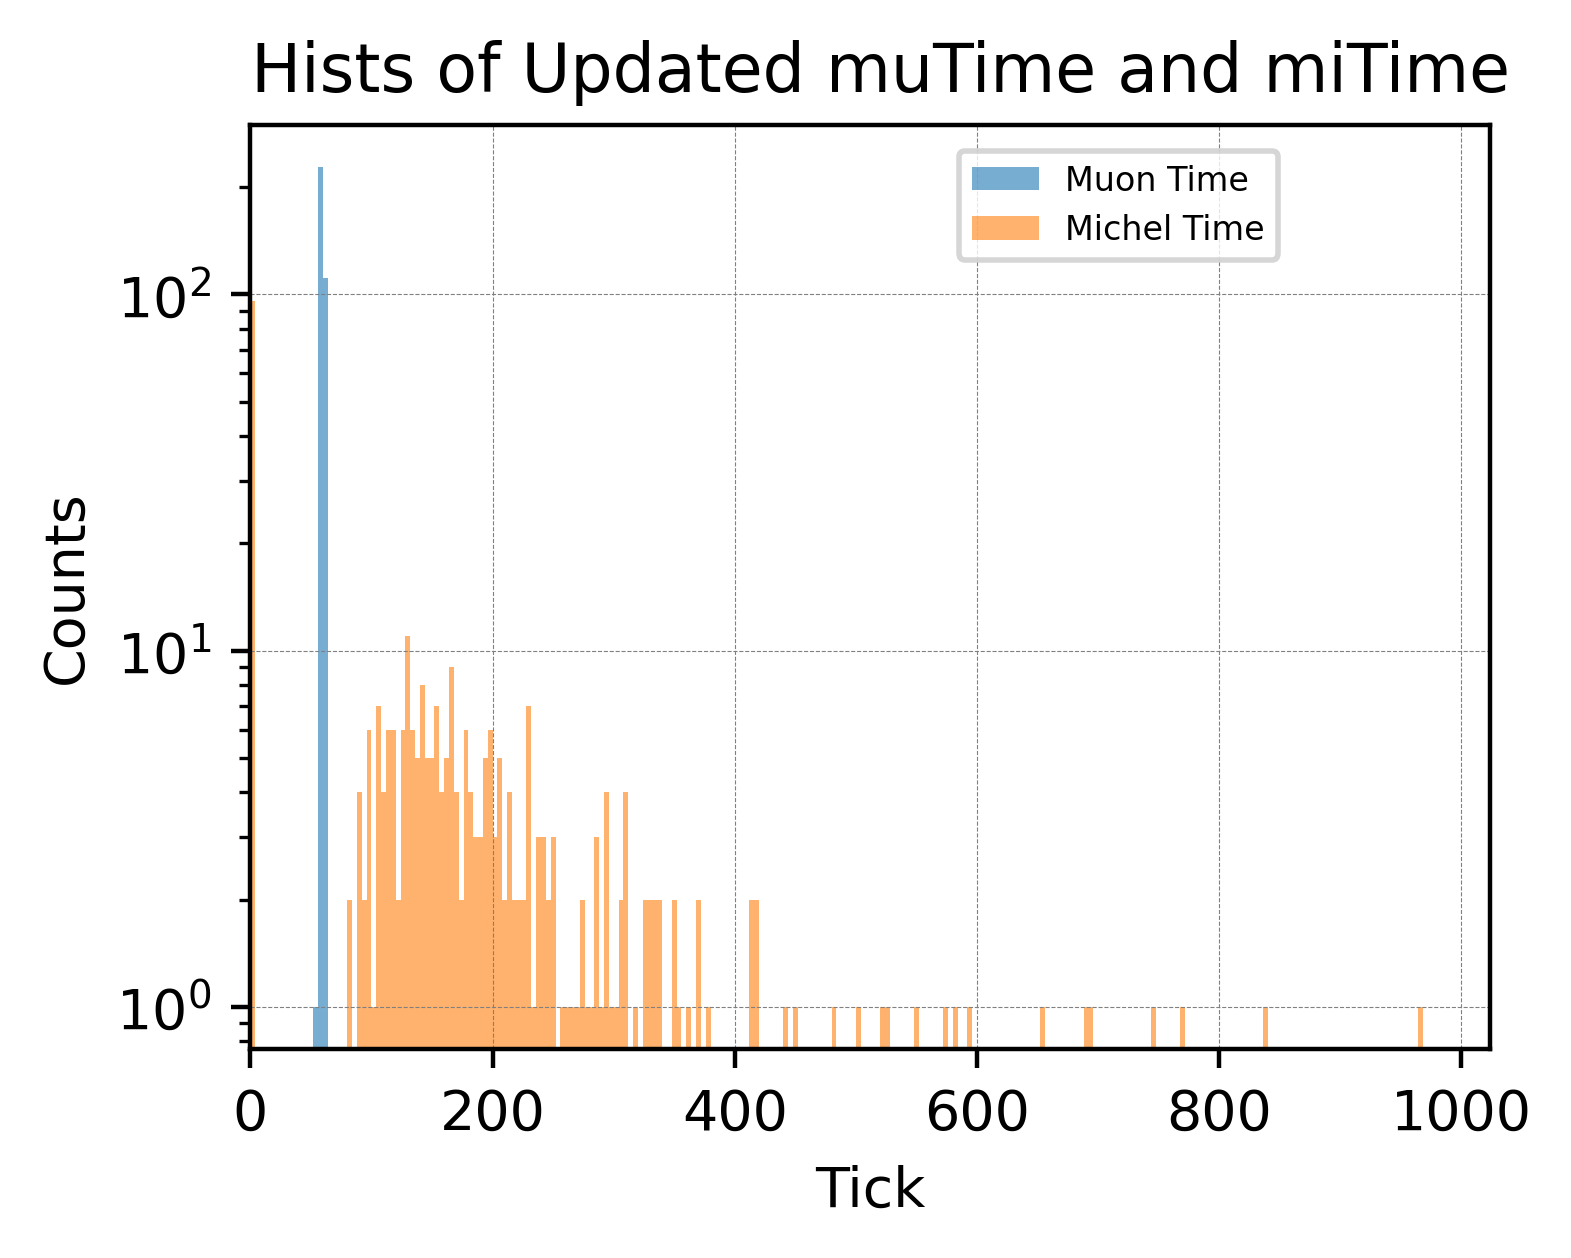

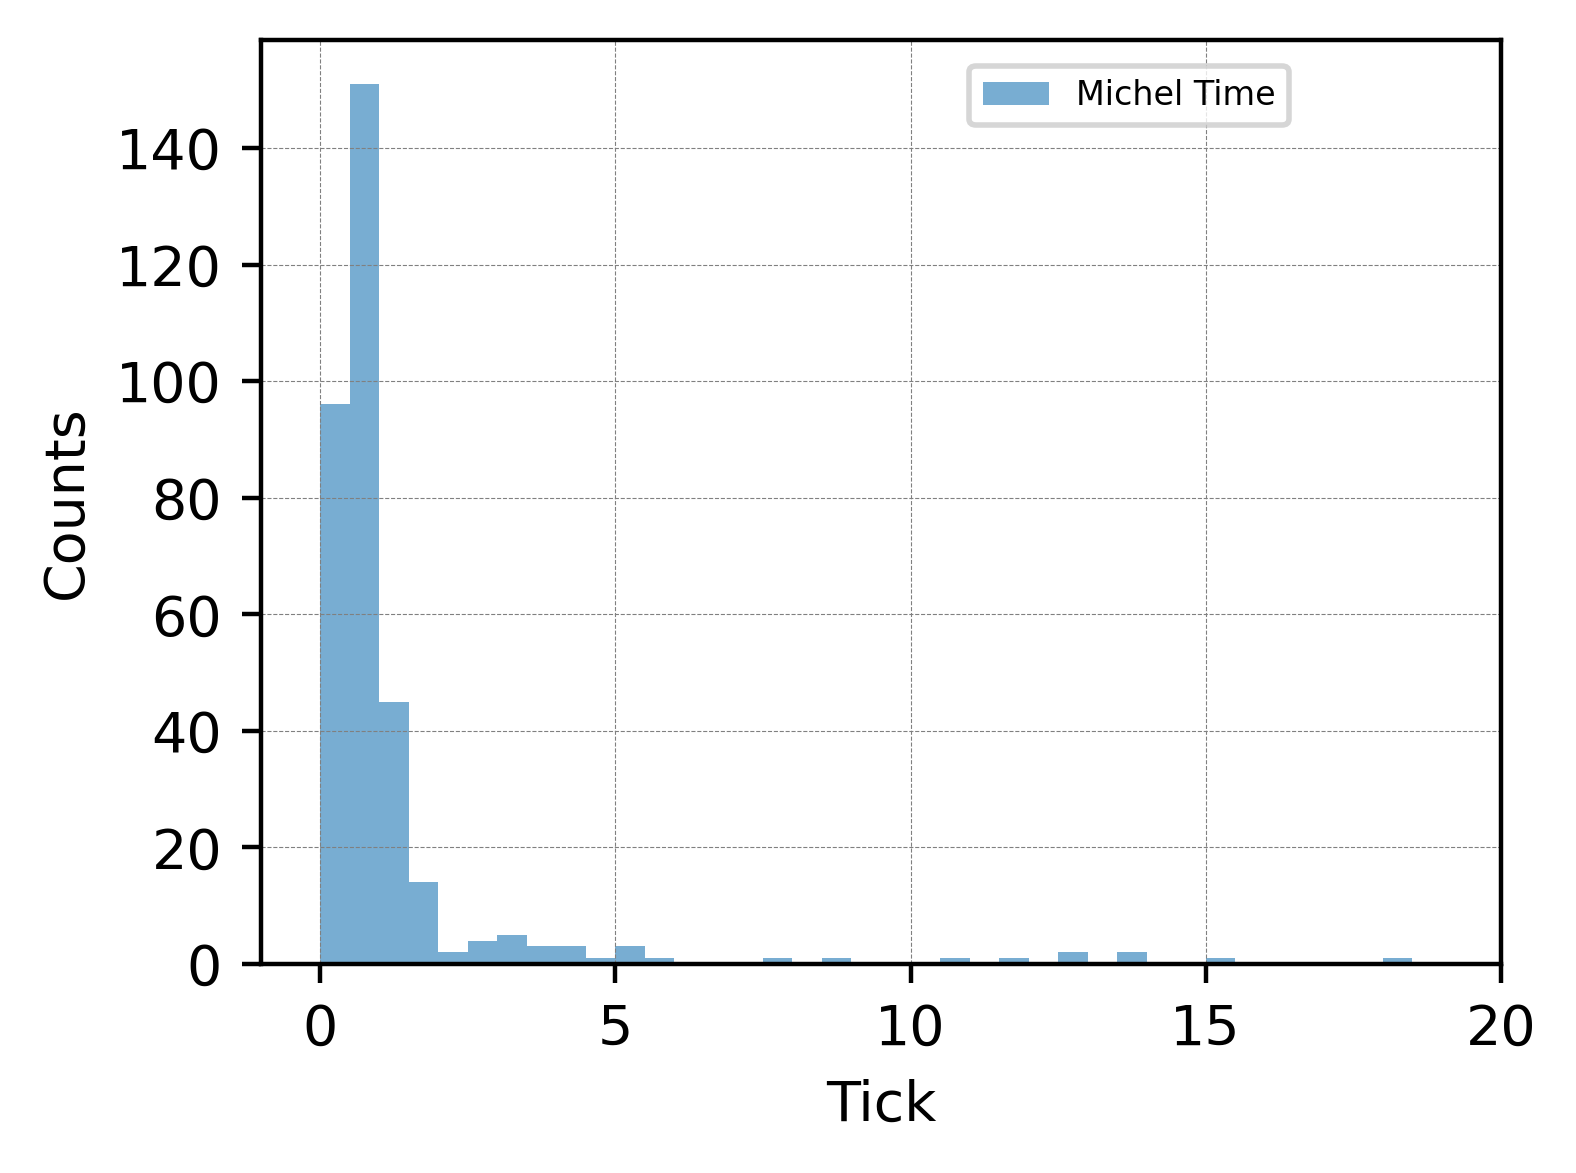

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


#Muon lifetime calculation-------------------------------------------------------------
# Only save muon time located in [55, 65]---
muTime_update = []
miTime_update = []
muIntensity_update = []
miIntensity_update = []

for i in range(0, len(mu_time)):
    mu = mu_time[i]
    mi = michel_time[i]
    muInten = mu_intensity[i]
    miInten = michel_intensity[i]

    if 55 <= mu <= 65:
        muTime_update.append(mu)
        miTime_update.append(mi)
        muIntensity_update.append(muInten)
        miIntensity_update.append(miInten)

print("\nMuon events purification (mu peak constrained to [55, 65]):")
print("\nPurified Muon events: ", len(muTime_update),
       "({:.2f}%)".format(len(muTime_update)/len(mu_time)*100))

print("Length of updated michel_time      : ", len(miTime_update))
print("Length of updated mu_intensity     : ", len(muIntensity_update))
print("Length of updated michel_intensity : ", len(miIntensity_update))

# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(miTime_update, muTime_update)]
print("Length of mu_lifetime (Updated): ", len(mu_lifetime))








#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title(' Hists of Updated muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()





#Initial Mu and Michel intensity distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 0.5  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
#plt.hist(muIntensity_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miIntensity_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-1, 20)
#plt.title(' Hists of Updated muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()





<br />
<br />
<br />
<br />


## Distribution in space:

In [14]:
#2nd & 3rd PDS groups---
decayX = []
decayY = []
decayZ = []




with open('./statResult/posX_extract_2ndPDS.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX.append(float(currentPlace))
with open('./statResult/posY_extract_2ndPDS.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY.append(float(currentPlace))
with open('./statResult/posZ_extract_2ndPDS.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ.append(float(currentPlace))

with open('./statResult/posX_extract_3rdPDS.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX.append(float(currentPlace))
with open('./statResult/posY_extract_3rdPDS.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY.append(float(currentPlace))
with open('./statResult/posZ_extract_3rdPDS.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ.append(float(currentPlace))



print("Length of decayX:", len(decayX))
print("Length of decayY:", len(decayY))
print("Length of decayZ:", len(decayZ))

Length of decayX: 344
Length of decayY: 344
Length of decayZ: 344


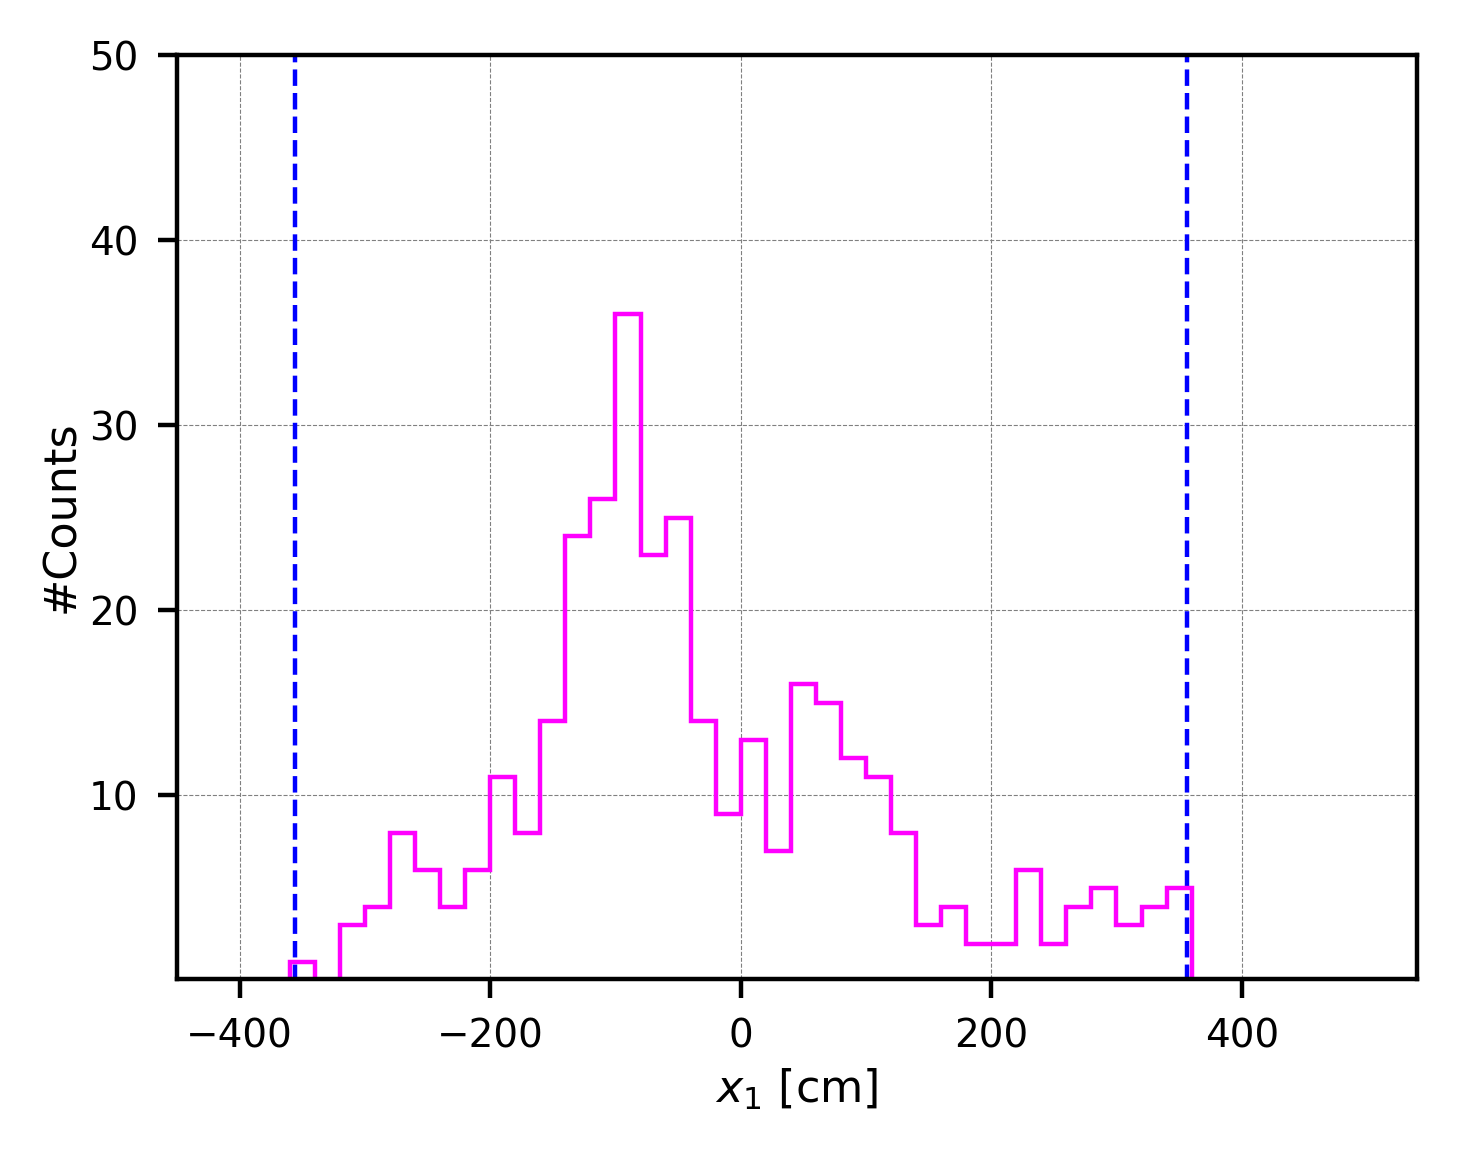

[0, 0, 1, 0, 3, 4, 8, 6, 4, 6, 11, 8, 14, 24, 26, 36, 23, 25, 14, 9, 13, 7, 16, 15, 12, 11, 8, 3, 4, 2, 2, 6, 2, 4, 5, 3, 4, 5, 0, 0]


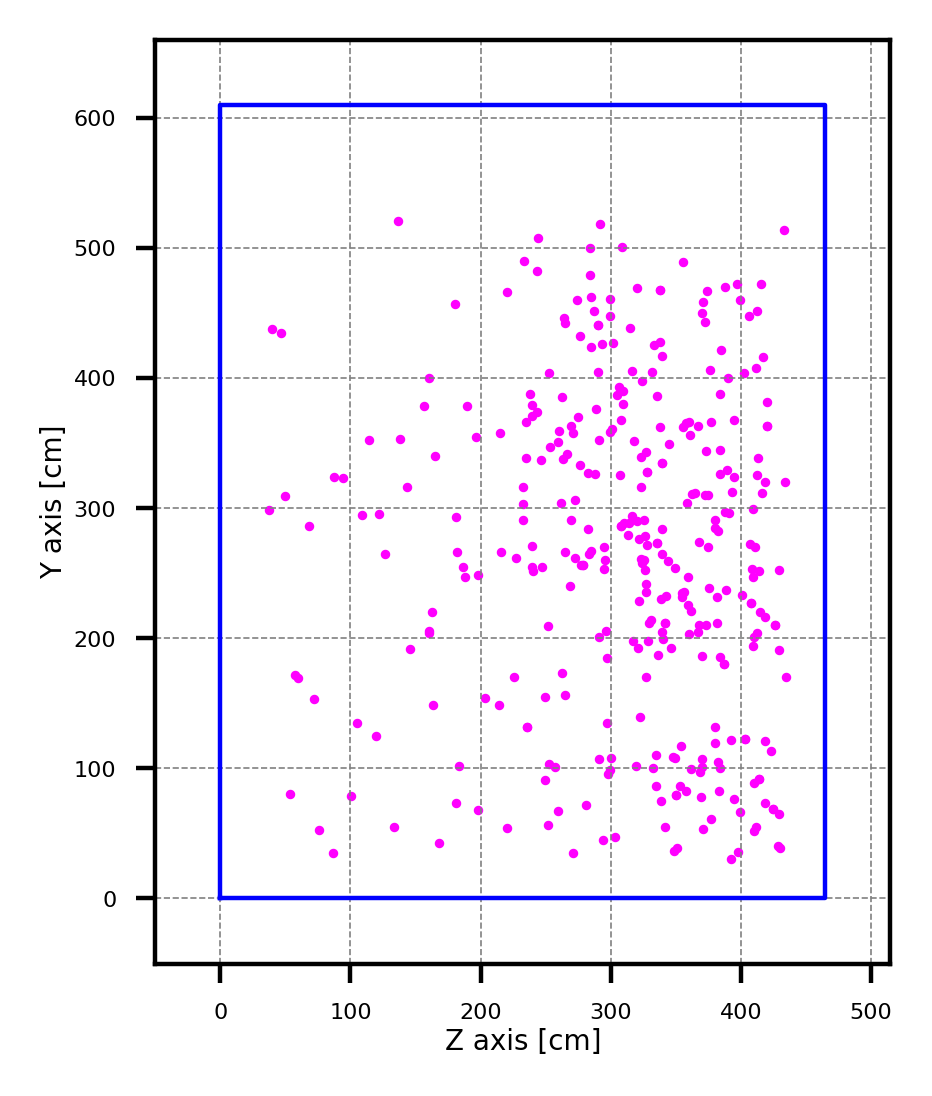

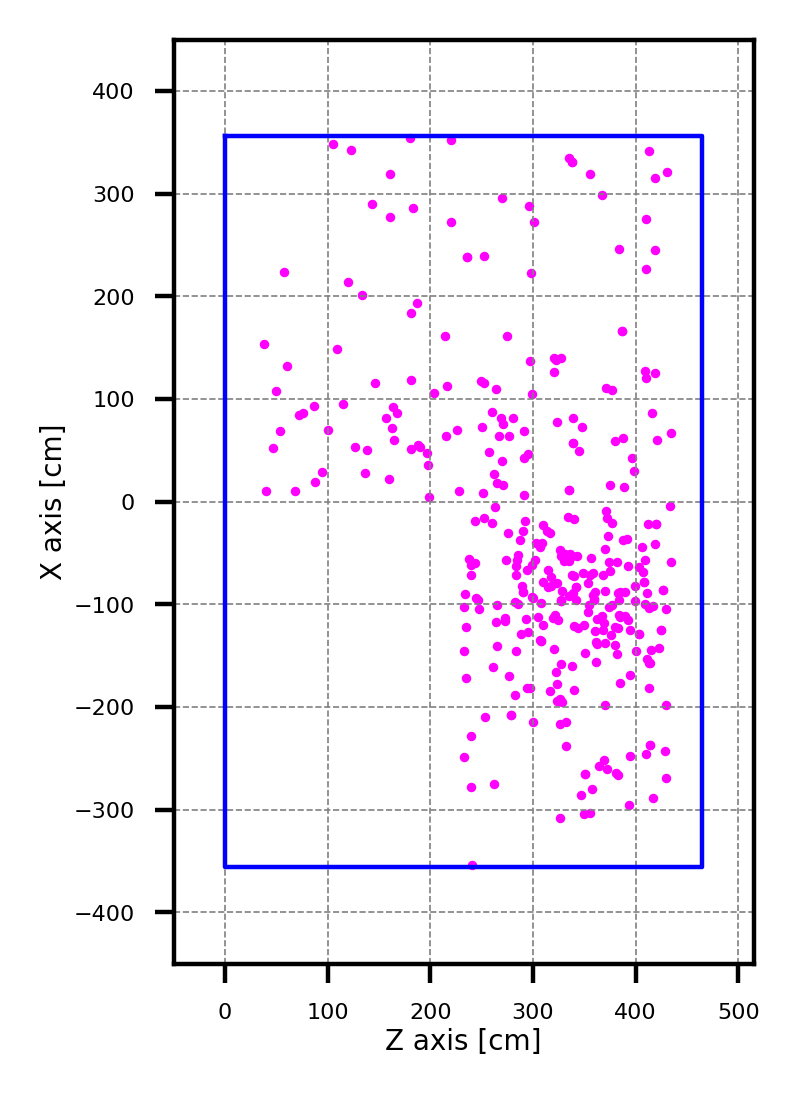

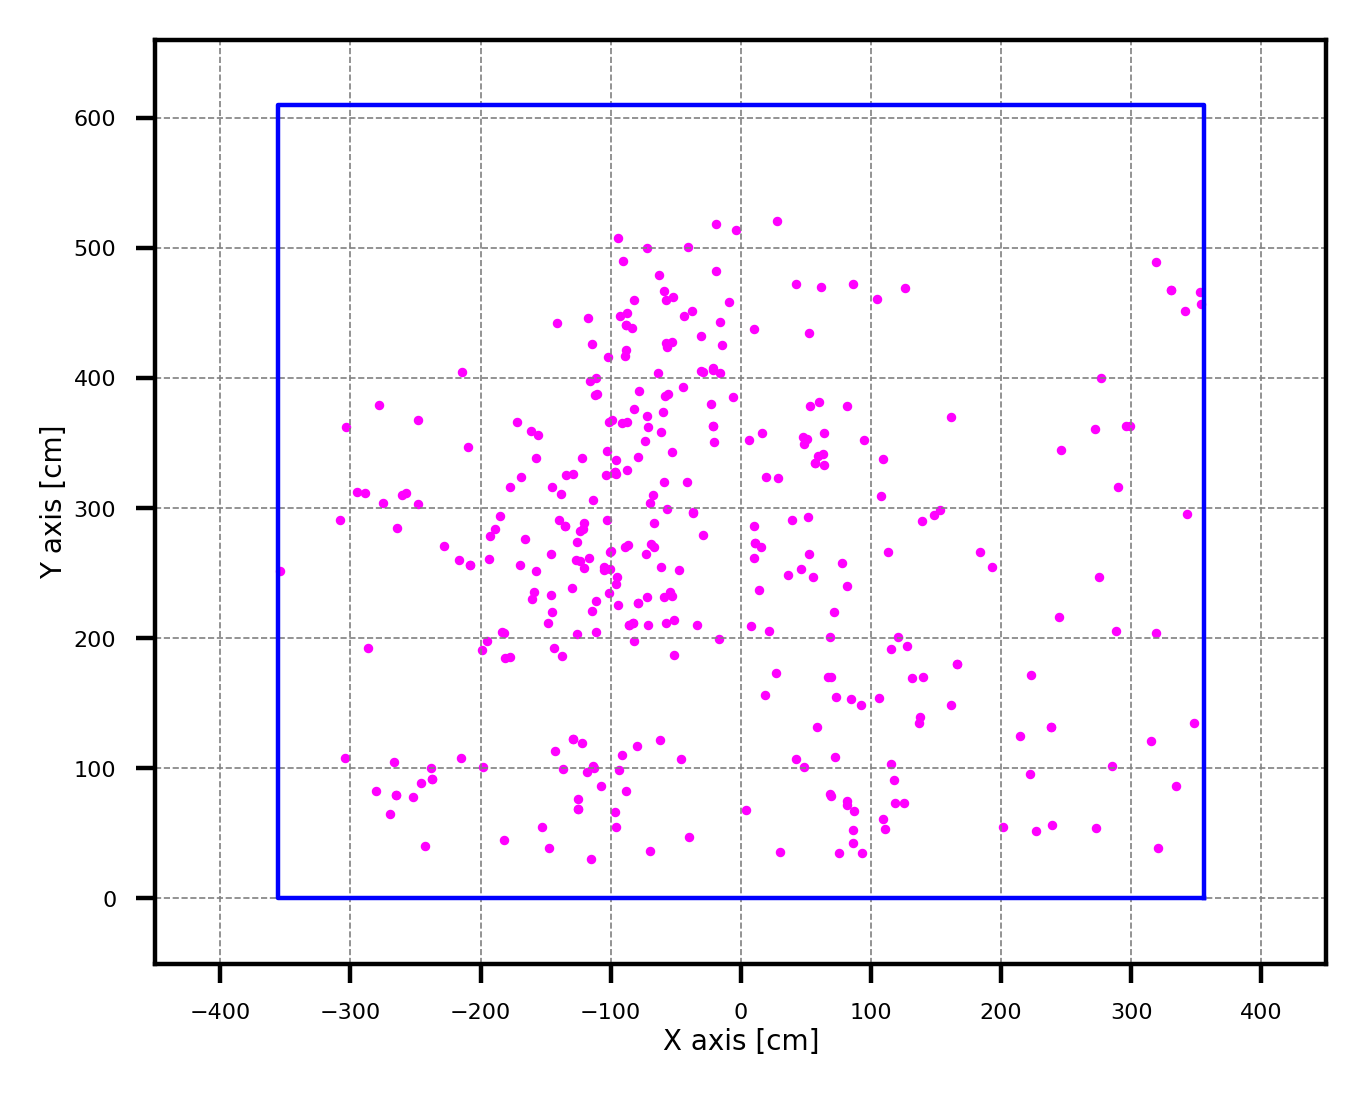

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)
#APA planes---
plt.plot([-356, -356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
#Define the range and bin width
bin_width = 20
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 50)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()  

# Compute histogram and print bin entries as a list
hist_counts, bin_edges = np.histogram(decayX, bins=bins, range=(range_min, range_max))
print(hist_counts.tolist())



#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayZ, decayY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayZ, decayX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayX, decayY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 


